
# 📘 Module 20: AdaBoost (Adaptive Boosting) – Practice Notebook

This is a **full practice notebook with detailed guidance and TODO blocks**.


## 0. Notebook Setup

We start by importing all required libraries.  


In [7]:
# TODO: Import all required libraries (Done for you)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression


## 1. Understanding the Dataset

You can begin with a **synthetic binary classification dataset**. or with any exisiting dataset.

Focus questions:
- Are the classes easily separable?
- Will a weak learner struggle?


In [3]:
# TODO: Generate a binary classification dataset
# Hint:
# - n_samples around 500
# - n_features = 2
# - class_sep > 1

# Generate binary classification dataset
X, y = make_classification(
    n_samples=500,        # around 500 samples
    n_features=2,         # 2 features
    n_informative=2,      # both features informative
    n_redundant=0,        # no redundant features
    n_clusters_per_class=1,
    class_sep=1.5,        # >1 for good separation
    random_state=42
)



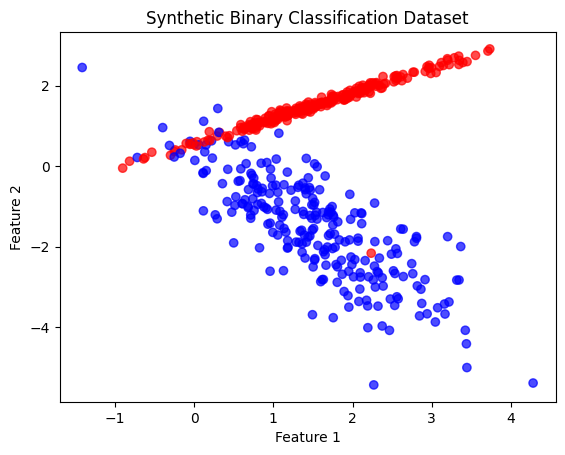

In [4]:
# TODO: Visualize the dataset using a scatter plot
# Color points by class label

# plt.scatter(...)
# plt.show()
# Quick 2D visualization
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.7)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Synthetic Binary Classification Dataset')
plt.show()


## 2. Train–Test Split

Before any model training, we split the data.

Why?
- To evaluate generalization
- To avoid lying to ourselves

Standard split:
- 70% training
- 30% testing


In [5]:
# TODO: Split the dataset into training and testing sets
# Use test_size=0.3 and random_state=42
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,       # 30% for testing
    random_state=42
)

# Optional: check the shapes
print("Training set:", X_train.shape, y_train.shape)
print("Testing set:", X_test.shape, y_test.shape)

Training set: (350, 2) (350,)
Testing set: (150, 2) (150,)



## 3. Baseline Weak Learner (Decision Stump)

Before AdaBoost, we test **one weak learner alone**.

We intentionally restrict the model:
- max_depth = 1
- This is called a **decision stump**

Expectation:
- Accuracy will not be impressive
- That is the point


In [8]:
# TODO: Create a DecisionTreeClassifier with max_depth=1
# SVM, Logistic Regression
# This is our weak learner

# 1. Decision Tree with max_depth=1 (weak learner)
dt = DecisionTreeClassifier(max_depth=1, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree (max_depth=1) Accuracy:", acc_dt)

# 2. Linear SVM (weak learner)
svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)
print("Linear SVM Accuracy:", acc_svm)

# 3. Logistic Regression (weak learner)
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", acc_lr)

Decision Tree (max_depth=1) Accuracy: 0.94
Linear SVM Accuracy: 0.9133333333333333
Logistic Regression Accuracy: 0.9133333333333333


In [9]:
# TODO: Train the weak learner
# TODO: Predict on test data
# TODO: Calculate and print accuracy
# --- Create the weak learner ---
weak_learner = DecisionTreeClassifier(max_depth=1, random_state=42)

# --- Train the weak learner ---
weak_learner.fit(X_train, y_train)

# --- Predict on test data ---
y_pred = weak_learner.predict(X_test)

# --- Calculate and print accuracy ---
accuracy = accuracy_score(y_test, y_pred)
print("Weak Learner Accuracy:", accuracy)

Weak Learner Accuracy: 0.94



## 4. AdaBoost Classifier – Core Practice

Now we combine **many weak learners** using AdaBoost.

Key idea:
- Each learner focuses more on previous mistakes
- Misclassified samples get more attention
- Correctly classified samples slowly matter less


In [13]:
# TODO: Initialize AdaBoostClassifier
# Use:
# - base_estimator = decision stump
# - n_estimators = 50
# - learning_rate = 1.0

# --- Base learner: Decision stump ---
stump = DecisionTreeClassifier(max_depth=1, random_state=42)

# --- Initialize AdaBoost ---
ada = AdaBoostClassifier(
    base_estimator=stump,
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

# --- Train AdaBoost on the training data ---
ada.fit(X_train, y_train)

# --- Predict on test data ---
y_pred_ada = ada.predict(X_test)

# --- Calculate and print accuracy ---
acc_ada = accuracy_score(y_test, y_pred_ada)
print("AdaBoost Accuracy:", acc_ada)

TypeError: AdaBoostClassifier.__init__() got an unexpected keyword argument 'base_estimator'

In [12]:
# TODO: Train AdaBoost on training data
# TODO: Predict on test data
# TODO: Evaluate accuracy
# TODO: Print classification report
# --- Base learner: decision stump ---
stump = DecisionTreeClassifier(max_depth=1, random_state=42)

# --- Initialize AdaBoost ---
ada = AdaBoostClassifier(
    estimator=stump,      # 'estimator' is used in recent scikit-learn
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

# --- Train AdaBoost on training data ---
ada.fit(X_train, y_train)

# --- Predict on test data ---
y_pred_ada = ada.predict(X_test)

# --- Evaluate accuracy ---
acc_ada = accuracy_score(y_test, y_pred_ada)
print("AdaBoost Accuracy:", acc_ada)

# --- Print classification report ---
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ada))

AdaBoost Accuracy: 0.9333333333333333

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.94        75
           1       0.96      0.91      0.93        75

    accuracy                           0.93       150
   macro avg       0.93      0.93      0.93       150
weighted avg       0.93      0.93      0.93       150




## 5. Weak Learner vs AdaBoost Comparison

Now we compare:
- One weak learner
- Many weak learners working together

Expectation:
- AdaBoost should outperform a single stump
- If not, something is wrong


In [14]:
# TODO: Create a comparison table
# Columns:
# - Model
# - Accuracy

# --- Single weak learner ---
stump = DecisionTreeClassifier(max_depth=1, random_state=42)
stump.fit(X_train, y_train)
y_pred_stump = stump.predict(X_test)
acc_stump = accuracy_score(y_test, y_pred_stump)

# --- AdaBoost with multiple stumps ---
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)
acc_ada = accuracy_score(y_test, y_pred_ada)

# --- Create comparison table ---
comparison_df = pd.DataFrame({
    'Model': ['Single Stump', 'AdaBoost (50 Stumps)'],
    'Accuracy': [acc_stump, acc_ada]
})

print(comparison_df)


                  Model  Accuracy
0          Single Stump  0.940000
1  AdaBoost (50 Stumps)  0.933333



## 6. Effect of Number of Estimators

AdaBoost performance depends heavily on:
- Number of estimators

More is not always better.

Your job:
- Experiment
- Observe
- Plot


In [16]:
# TODO: Try different n_estimators values
# Example: [5, 10, 20, 50, 100]

# Store accuracy for each value


# Different n_estimators to test
n_estimators_list = [5, 10, 20, 50, 100]
accuracies = []

for n in n_estimators_list:
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=n,
        learning_rate=1.0,
        random_state=42
    )
    ada.fit(X_train, y_train)
    y_pred = ada.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"n_estimators = {n}, Accuracy = {acc:.4f}")



n_estimators = 5, Accuracy = 0.8867
n_estimators = 10, Accuracy = 0.8867
n_estimators = 20, Accuracy = 0.8867
n_estimators = 50, Accuracy = 0.9333
n_estimators = 100, Accuracy = 0.9333


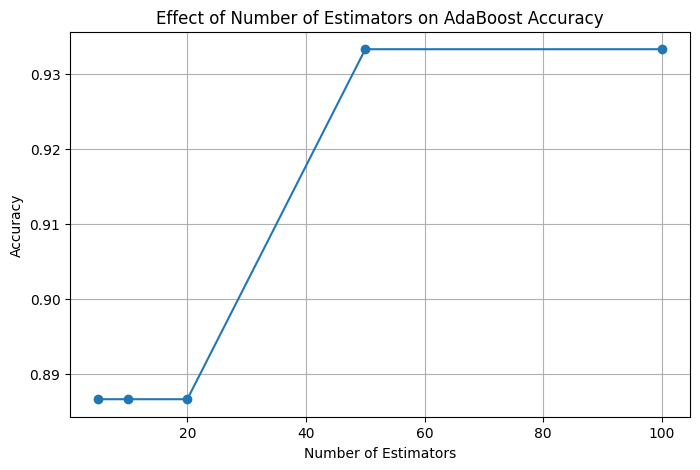

In [17]:
# TODO: Plot n_estimators vs accuracy
# Label axes clearly

# Plot the effect of n_estimators
plt.figure(figsize=(8,5))
plt.plot(n_estimators_list, accuracies, marker='o')
plt.title("Effect of Number of Estimators on AdaBoost Accuracy")
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


## 7. Effect of Learning Rate

Learning rate controls **how aggressively** AdaBoost updates sample weights.

Intuition:
- High learning rate → fast but risky
- Low learning rate → slow but stable

You will verify this experimentally.


In [18]:
# TODO: Experiment with different learning_rate values
# Example: [0.01, 0.1, 0.5, 1.0]

# Different learning rates to try
learning_rates = [0.01, 0.1, 0.5, 1.0]
accuracies = []

for lr in learning_rates:
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=50,      # keep number of estimators constant
        learning_rate=lr,
        random_state=42
    )
    ada.fit(X_train, y_train)
    y_pred = ada.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"Learning rate = {lr}, Accuracy = {acc:.4f}")

Learning rate = 0.01, Accuracy = 0.9400
Learning rate = 0.1, Accuracy = 0.9400
Learning rate = 0.5, Accuracy = 0.9067
Learning rate = 1.0, Accuracy = 0.9333


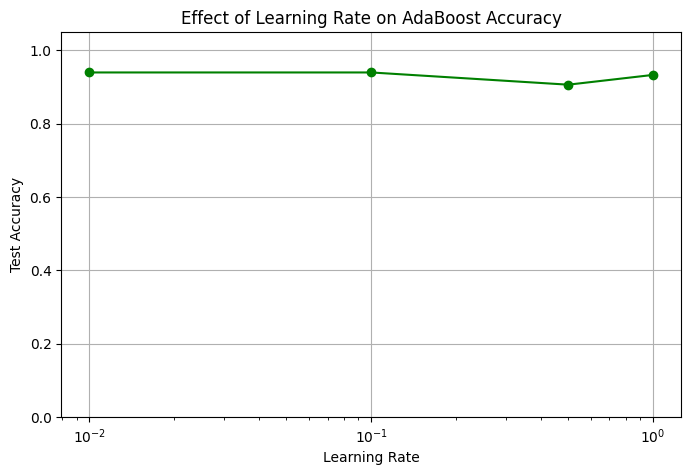

In [19]:
# TODO: Plot learning_rate vs accuracy

# Plot the effect of learning rate
plt.figure(figsize=(8,5))
plt.plot(learning_rates, accuracies, marker='o', linestyle='-', color='green')
plt.title("Effect of Learning Rate on AdaBoost Accuracy")
plt.xlabel("Learning Rate")
plt.ylabel("Test Accuracy")
plt.xscale('log')  # log scale can help visualize small values
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()


## 8. Feature Importance in AdaBoost

AdaBoost can tell us:
- Which features were more influential

This depends on:
- How often a feature is used in splits
- How strong the corresponding learners were


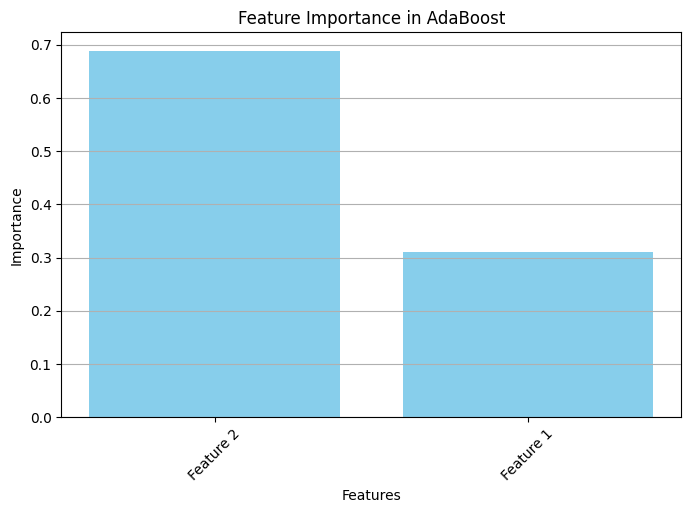

In [20]:
# TODO: Extract feature importance from AdaBoost
# TODO: Plot feature importance

# --- Train AdaBoost ---
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)
ada.fit(X_train, y_train)

# --- Extract feature importance ---
# AdaBoost aggregates feature importances from all weak learners
feature_importances = ada.feature_importances_

# If using a dataset with feature names (like breast_cancer), you can do:
# feature_names = data.feature_names
# Otherwise, use generic names
feature_names = [f'Feature {i+1}' for i in range(X.shape[1])]

# Create a DataFrame for easier plotting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# --- Plot feature importance ---
plt.figure(figsize=(8,5))
plt.bar(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.title("Feature Importance in AdaBoost")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


## 9. Reflection (Mandatory)

Answer in your own words.

1. Why is AdaBoost called *adaptive*?
2. What happens to misclassified samples after each iteration?
3. Why do we prefer weak learners instead of strong ones?
4. When should AdaBoost not be used?


1. Why is AdaBoost called adaptive?

  AdaBoost is called adaptive because it adjusts the training process based on the mistakes of previous models. After each weak learner is trained, the algorithm increases the weight of the samples that were misclassified, so the next learner focuses more on the “hard” examples. This way, the ensemble adapts to the data progressively.

2. What happens to misclassified samples after each iteration?

  Misclassified samples get higher weights in the next iteration. This means the next weak learner will pay more attention to these difficult samples, trying to correct the mistakes of previous learners.

3. Why do we prefer weak learners instead of strong ones?

  Weak learners are simple models (like decision stumps) that perform slightly better than random guessing. They are preferred because:

* They are fast to train.

* AdaBoost combines many weak learners to build a strong ensemble.

* Using strong learners could lead to overfitting quickly and makes the adaptive weighting less effective.

4. When should AdaBoost not be used?

  AdaBoost may not be suitable when:

* The data contains a lot of noise or mislabeled samples, because the algorithm will focus too much on these errors and overfit.

* The dataset is very large, as AdaBoost can be computationally expensive with many iterations.

* Weak learners are already too strong, making boosting unnecessary and possibly unstable.


## 10. Bonus Challenge (Optional)

Replace the decision stump with **Logistic Regression** as the base estimator.

Questions:
- Does AdaBoost still work?
- Should you do this in practice?
- Why or why not?


In [22]:
# --- Define base learners ---
base_learners = {
    'Decision Stump': DecisionTreeClassifier(max_depth=1, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),

}

# --- Store results ---
results = []

for name, learner in base_learners.items():
    ada = AdaBoostClassifier(
        estimator=learner,
        n_estimators=50,
        learning_rate=1.0,
        random_state=42
    )
    ada.fit(X_train, y_train)
    y_pred = ada.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({'Base Learner': name, 'AdaBoost Accuracy': acc})

    # Optional: print classification report for Logistic Regression only
    if name == 'Logistic Regression':
        print(f"\nClassification Report for AdaBoost with {name}:")
        print(classification_report(y_test, y_pred))

# --- Create comparison table ---
comparison_df = pd.DataFrame(results)
print("\nComparison of AdaBoost with Different Base Learners:")
print(comparison_df)


Classification Report for AdaBoost with Logistic Regression:
              precision    recall  f1-score   support

           0       0.86      0.99      0.92        75
           1       0.98      0.84      0.91        75

    accuracy                           0.91       150
   macro avg       0.92      0.91      0.91       150
weighted avg       0.92      0.91      0.91       150


Comparison of AdaBoost with Different Base Learners:
          Base Learner  AdaBoost Accuracy
0       Decision Stump           0.933333
1  Logistic Regression           0.913333
